# New Section

In [ ]:
%cd EmbeddinglessNMT

/content/EmbeddinglessNMT
Obtaining file:///content/EmbeddinglessNMT
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [30]:
!pip install --editable ./
!apt-get install bc
!pip install fairseq

Obtaining file:///content/drive/MyDrive/Colab%20Notebooks/ECE570/EmbeddinglessNMT
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for fairseq (pyproject.toml) ... done
  Created wheel for fairseq: filename=fairseq-0.9.0-0.editable-cp311-cp311-linux_x86_64.whl size=5227 sha256=a51a47567a9c23d20f4794829061c12534f3b8fe50ee177b0db0c0fd59c95ada
  Stored in directory: /tmp/pip-ephem-wheel-cache-3zb260j5/wheels/95/46/3a/128a63fcc285b8ef9460e8aba60d25ce161f3730b6e33fd183
Successfully built fairseq
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
bc is already the newest version (1.07.1-3build1).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.


In [ ]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [ ]:
!bash embeddingless_scripts/ch_sg/prepare-de-data.sh

======= Creating raw data for de-en =======
Running prepare-iwslt-raw.sh..
unzipping de-en.tgz
de-en/
de-en/IWSLT14.TED.dev2010.de-en.de.xml
de-en/IWSLT14.TED.dev2010.de-en.en.xml
de-en/IWSLT14.TED.tst2010.de-en.de.xml
de-en/IWSLT14.TED.tst2010.de-en.en.xml
de-en/IWSLT14.TED.tst2011.de-en.de.xml
de-en/IWSLT14.TED.tst2011.de-en.en.xml
de-en/IWSLT14.TED.tst2012.de-en.de.xml
de-en/IWSLT14.TED.tst2012.de-en.en.xml
de-en/IWSLT14.TEDX.dev2012.de-en.de.xml
de-en/IWSLT14.TEDX.dev2012.de-en.en.xml
de-en/README
de-en/train.en
de-en/train.tags.de-en.de
de-en/train.tags.de-en.en
pre-processing train data...


Original src data had 174443 examples
clean-corpus.perl: processing iwslt14.de-en/tmp/train.tags.de-en.de & .en to iwslt14.de-en/tmp/train.tags.de-en.clean, cutoff 1-800, ratio 9999999
..........(100000).......
Input sentences: 174443  Output sentences:  174350
Percentage of sentences removed by length filter: 1%
Cleaned data has 165720 examples
Total percentage of sentences removed by cleani

In [ ]:
!export CUDA_VISIBLE_DEVICES=0

!bash embeddingless_scripts/ch_sg/byte/run_de_en_byte_drop_02.sh

2025-04-13 18:13:52.898159: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744568032.932253   15236 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744568032.939715   15236 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-13 18:14:15 | INFO | fairseq_cli.train | Namespace(no_progress_bar=False, log_interval=100, log_format=None, tensorboard_logdir='tensorboard/byte_de_en_14_0.2', seed=1, cpu=False, tpu=False, bf16=False, fp16=False, memory_efficient_bf16=False, memory_efficient_fp16=False, fp16_no_flatten_grads=False, fp16_init_scale=128, fp16_scale_window=None, fp16_scale_tolerance=0.0, min_loss_scale=0.0001, threshold_loss_scale=None, user_d

In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

log_data = """
epoch 001: 100% 310/311 [20:41<00:03,  3.95s/it, loss=4.664, nll_loss=4.113, ppl=17.3, wps=12513.9, ups=0.25, wpb=50039, bsz=510.4, num_updates=300, lr=3.75925e-05, gnorm=0.894, train_wall=399, wall=1209]
epoch 002: 100% 310/311 [20:39<00:03,  3.98s/it, loss=4.051, nll_loss=3.397, ppl=10.54, wps=12489.8, ups=0.25, wpb=49857.2, bsz=518.5, num_updates=600, lr=7.5085e-05, gnorm=1.063, train_wall=398, wall=2437]
epoch 003: 100% 310/311 [20:40<00:04,  4.03s/it, loss=3.719, nll_loss=3.015, ppl=8.08, wps=12457.2, ups=0.25, wpb=49466.1, bsz=520.6, num_updates=900, lr=0.000112578, gnorm=1.025, train_wall=396, wall=3663]
epoch 004: 100% 310/311 [20:42<00:03,  3.95s/it, loss=3.445, nll_loss=2.702, ppl=6.51, wps=12456.9, ups=0.25, wpb=49875.4, bsz=486.4, num_updates=1200, lr=0.00015007, gnorm=0.828, train_wall=399, wall=4892]
epoch 005: 100% 310/311 [20:40<00:04,  4.09s/it, loss=3.218, nll_loss=2.442, ppl=5.44, wps=12476.3, ups=0.25, wpb=49975.2, bsz=509.2, num_updates=1500, lr=0.000187563, gnorm=0.719, train_wall=400, wall=6120]
epoch 006: 100% 310/311 [20:39<00:03,  3.94s/it, loss=3.04, nll_loss=2.239, ppl=4.72, wps=12472.5, ups=0.25, wpb=49842.3, bsz=509.6, num_updates=1800, lr=0.000225055, gnorm=0.628, train_wall=399, wall=7353]
epoch 007: 100% 310/311 [20:38<00:04,  4.01s/it, loss=2.921, nll_loss=2.103, ppl=4.3, wps=12487.3, ups=0.25, wpb=49768.1, bsz=509.7, num_updates=2100, lr=0.000262548, gnorm=0.595, train_wall=398, wall=8580]
epoch 008: 100% 310/311 [20:36<00:04,  4.04s/it, loss=2.829, nll_loss=1.999, ppl=4, wps=12459, ups=0.25, wpb=49890.3, bsz=487.8, num_updates=2400, lr=0.00030004, gnorm=0.559, train_wall=399, wall=9806]
epoch 009:  95% 294/311 [19:32<01:08,  4.01s/it, loss=2.734, nll_loss=1.89, ppl=3.71, wps=12507.4, ups=0.25, wpb=49879.6, bsz=490.4, num_updates=2700, lr=0.000337533, gnorm=0.505, train_wall=398, wall=11036]
"""

pattern = r"epoch (\d+):.*?loss=([\d\.]+), nll_loss=([\d\.]+), ppl=([\d\.]+),.*?lr=([\deE\+\-\.]+), gnorm=([\d\.]+)"
matches = re.findall(pattern, log_data)

df = pd.DataFrame(matches, columns=["epoch", "loss", "nll_loss", "ppl", "lr", "gnorm"])
df["epoch"] = df["epoch"].astype(int)
df["loss"] = df["loss"].astype(float)
df["nll_loss"] = df["nll_loss"].astype(float)
df["ppl"] = df["ppl"].astype(float)
df["lr"] = df["lr"].astype(float)
df["gnorm"] = df["gnorm"].astype(float)

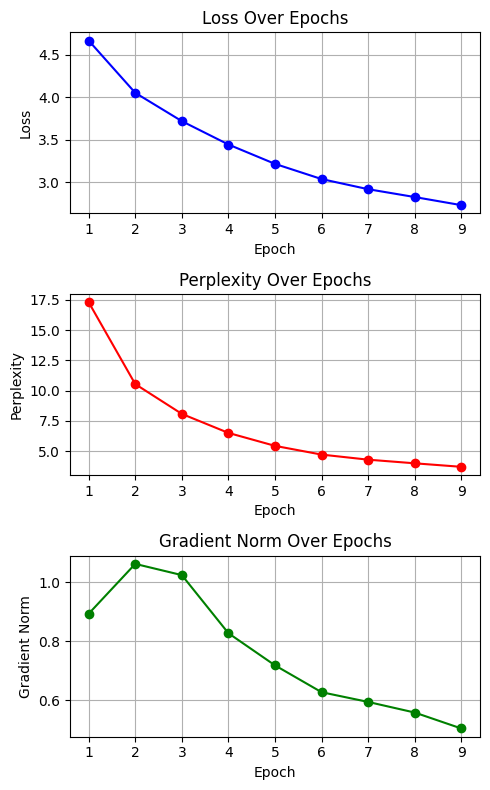

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(5, 8), sharex=False)

#loss
axes[0].plot(df["epoch"], df["loss"], color='blue', marker='o')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Over Epochs")
axes[0].grid(True)

#perplexity
axes[1].plot(df["epoch"], df["ppl"], color='red', marker='o')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity Over Epochs")
axes[1].grid(True)

#gradient norm
axes[2].plot(df["epoch"], df["gnorm"], color='green', marker='o')
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Gradient Norm")
axes[2].set_title("Gradient Norm Over Epochs")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
!pip uninstall -y fairseq
!pip install git+https://github.com/facebookresearch/fairseq.git

In [ ]:
!fairseq-generate data-bin \
    --path checkpoints/byte_de_en_14_0.2/checkpoint_best.pt \
    --beam 5 \
    --batch-size 32 \
    --remove-bpe \
    --sacrebleu \
    --gen-subset valid

In [ ]:
!fairseq-generate data-bin \
  --path checkpoints/your_checkpoint.pt \
  --beam 5 \
  --batch-size 32 \
  --remove-bpe \
  --gen-subset valid \
  --scoring chrf
